In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salahuddinahmedshuvo/student-mental-stress-and-coping-mechanisms")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 17.2k/17.2k [00:00<00:00, 3.51MB/s]

Extracting files...
Path to dataset files: C:\Users\anast\.cache\kagglehub\datasets\salahuddinahmedshuvo\student-mental-stress-and-coping-mechanisms\versions\1


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

# Configure inline plotting
%matplotlib inline

# Set visual styles
sns.set(style="whitegrid")
data = pd.read_csv(r'C:\Users\anast\.cache\kagglehub\datasets\salahuddinahmedshuvo\student-mental-stress-and-coping-mechanisms\versions\1\Student_Mental_Stress_and_Coping_Mechanisms.csv')
data

,Student ID,Age,Gender,Academic Performance (GPA),Study Hours Per Week,Social Media Usage (Hours per day),Sleep Duration (Hours per night),Physical Exercise (Hours per week),Family Support,Financial Stress,Peer Pressure,Relationship Stress,Mental Stress Level,Counseling Attendance,Diet Quality,Stress Coping Mechanisms,Cognitive Distortions,Family Mental Health History,Medical Condition,Substance Use
0,802-17-3671,22,Female,2,9,2,12,2,1,1,3,5,9,No,1,Walking or Nature Walks,4,No,Yes,1
1,871-12-8572,25,Female,0,28,0,6,0,1,1,1,2,9,Yes,3,Meditation,2,Yes,No,1
2,495-13-2672,24,Female,0,45,3,12,10,3,3,1,4,9,Yes,5,Reading,1,Yes,Yes,3
3,365-77-2496,20,Male,2,8,7,7,4,1,3,2,5,1,No,1,Social Media Engagement,2,Yes,No,4
4,664-76-5622,28,Male,0,14,6,8,1,2,4,4,2,7,Yes,1,Exercise,1,Yes,No,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,826-89-7993,24,Genderfluid,2,50,4,11,8,5,2,4,5,2,Yes,1,Exercise,3,Yes,No,2
756,681-15-6754,23,Female,3,5,6,12,7,1,4,2,1,1,Yes,2,Meditation,4,Yes,No,1
757,714-33-5373,23,Male,1,17,3,11,5,2,4,3,3,9,Yes,5,Social Media Engagement,4,Yes,No,3
758,849-54-1252,29,Female,1,15,8,10,4,2,1,2,2,2,No,4,Meditation,4,No,Yes,3


In [2]:
data.drop('Student ID',axis=1)
if set(data['Counseling Attendance'].str.lower().unique()) <= {"yes", "no"}:
    data['Counseling Attendance'] = data['Counseling Attendance'].str.lower().map({'yes': 1, 'no': 0})
else:
    le = LabelEncoder()
    data['Counseling Attendance'] = le.fit_transform(data['Counseling Attendance'])

df = pd.get_dummies(data, drop_first=True)

print("\nData after encoding:")
display(df.head())


Data after encoding:


,Age,Academic Performance (GPA),Study Hours Per Week,Social Media Usage (Hours per day),Sleep Duration (Hours per night),Physical Exercise (Hours per week),Family Support,Financial Stress,Peer Pressure,Relationship Stress,...,Stress Coping Mechanisms_Reading,Stress Coping Mechanisms_Social Media Engagement,Stress Coping Mechanisms_Spending Time Alone,Stress Coping Mechanisms_Talking to Friends,Stress Coping Mechanisms_Travelling,Stress Coping Mechanisms_Walking or Nature Walks,Stress Coping Mechanisms_Watching Sports,Stress Coping Mechanisms_Yoga,Family Mental Health History_Yes,Medical Condition_Yes
0,22,2,9,2,12,2,1,1,3,5,...,0,0,0,0,0,1,0,0,0,1
1,25,0,28,0,6,0,1,1,1,2,...,0,0,0,0,0,0,0,0,1,0
2,24,0,45,3,12,10,3,3,1,4,...,1,0,0,0,0,0,0,0,1,1
3,20,2,8,7,7,4,1,3,2,5,...,0,1,0,0,0,0,0,0,1,0
4,28,0,14,6,8,1,2,4,4,2,...,0,0,0,0,0,0,0,0,1,0


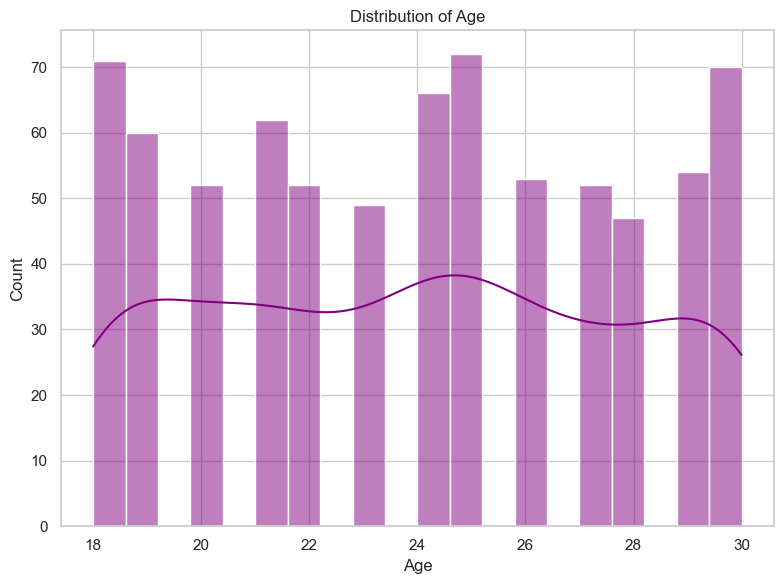

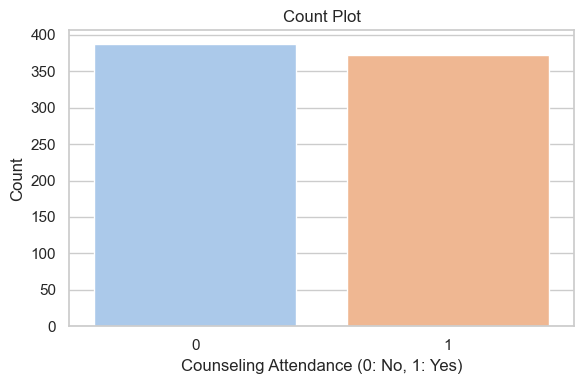

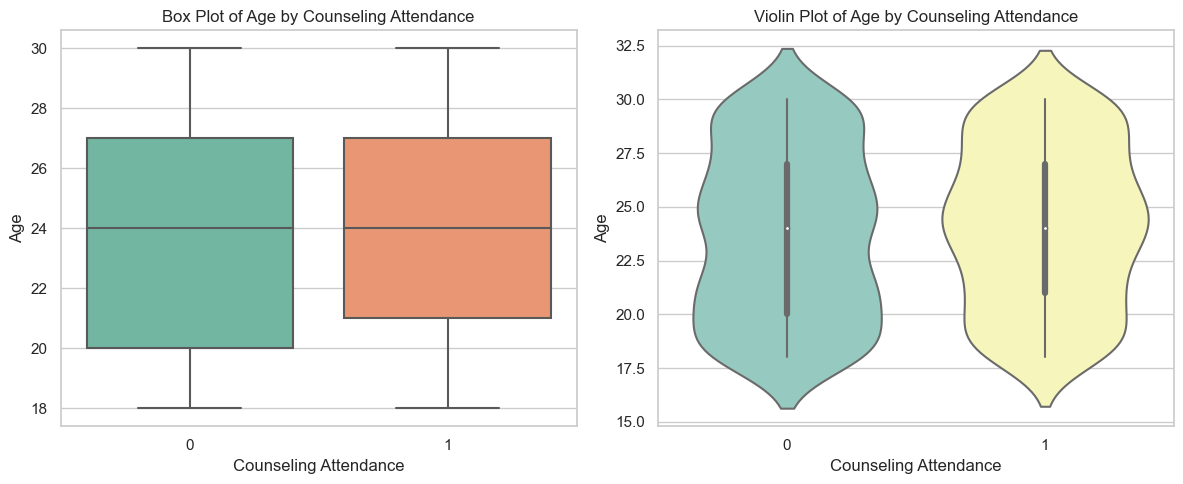

In [3]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], kde=True, bins=20, color='purple')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Count plot for the target variable 'Suicide Attempt'
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Counseling Attendance'], palette='pastel')
plt.title('Count Plot')
plt.xlabel('Counseling Attendance (0: No, 1: Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Box plot and violin plot for Age grouped by Suicide Attempt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['Counseling Attendance'], y=df['Age'], palette='Set2')
plt.title('Box Plot of Age by Counseling Attendance')

plt.subplot(1, 2, 2)
sns.violinplot(x=df['Counseling Attendance'], y=df['Age'], palette='Set3')
plt.title('Violin Plot of Age by Counseling Attendance')

plt.tight_layout()
plt.show()

Accuracy Score: 0.5724


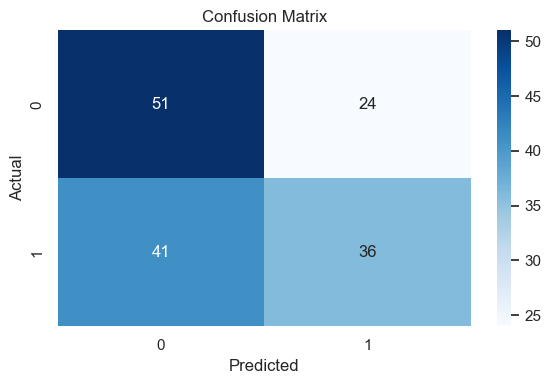

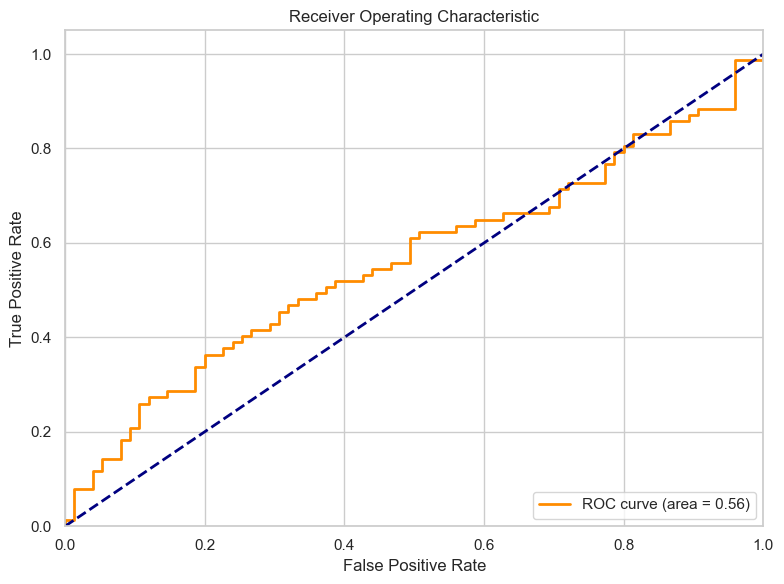

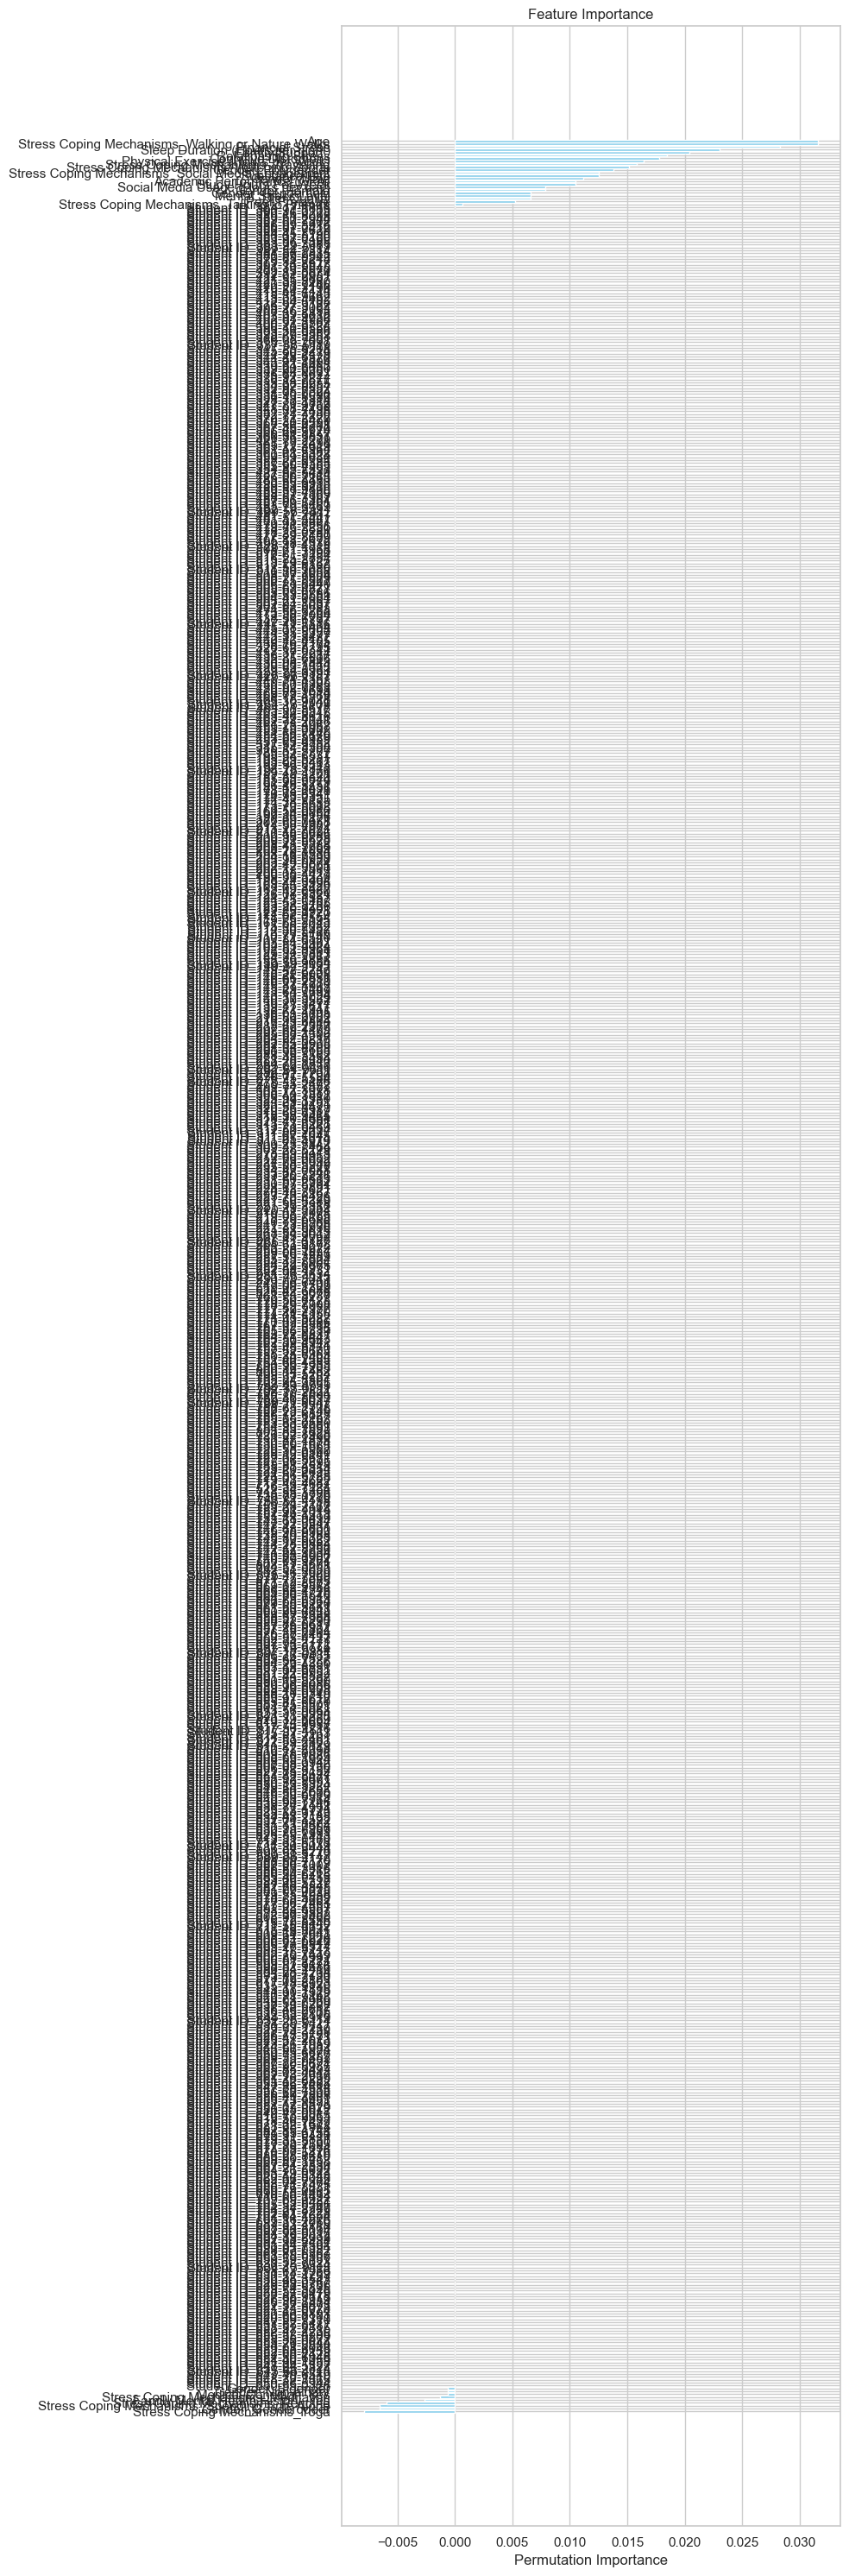

In [7]:
df.dropna(inplace=True)

# 2. Separate features (X) and target (y)
X = df.drop('Counseling Attendance', axis=1)
y = df['Counseling Attendance']

# 3. Check if the feature matrix is empty after dropping NaNs
if X.shape[0] == 0:
    raise ValueError('The feature matrix is empty after dropping NaNs. Check your data for extensive missing values.')

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Check if the training set is empty after splitting
if X_train.shape[0] == 0:
    raise ValueError('Training set is empty after splitting. Adjust the test_size or check the input data.')

# 6. Train the Logistic Regression model
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

# 7. Make predictions
y_pred = model.predict(X_test)

# 8. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 10. ROC Curve (only if the target variable has binary labels)
if set(y_test.unique()) <= {0, 1}:
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.')

# 11. Permutation Importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': result.importances_mean})
importance_df = importance_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 30))
plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [8]:
importance_df['abs_importance'] = abs(importance_df['importance'])  # Create a column with the absolute importance values
importance_df = importance_df.sort_values(by='abs_importance', ascending=False)
print("\nMost Important Features:")
print(importance_df.head())


Most Important Features:
                                              feature  importance  \
0                                                 Age    0.031579   
786  Stress Coping Mechanisms_Walking or Nature Walks    0.031579   
7                                    Financial Stress    0.028289   
4                    Sleep Duration (Hours per night)    0.023026   
6                                    Family Support      0.020395   

     abs_importance  
0          0.031579  
786        0.031579  
7          0.028289  
4          0.023026  
6          0.020395  
